# 05. 가드레일(Guardrails)

> 에이전트도 가드레일 없이 운영하면 사고가 나요. PII 4가지 처리 전략과 `@before_agent`/`@after_agent` 검증, Defense-in-Depth 원칙을 코드로 적용해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. **PII 보호**의 4가지 전략(redact, mask, hash, block)을 이해하고 `PIIMiddleware`를 적용할 수 있어요
2. 커스텀 정규 표현식으로 한국 전화번호, API 키 등 비즈니스 맞춤형 PII 탐지기를 만들 수 있어요
3. `@before_agent` / `@after_agent` 데코레이터와 `AgentMiddleware` 클래스로 커스텀 가드레일을 구현할 수 있어요
4. **계층화된 방어(Defense in Depth)** 전략으로 여러 가드레일을 올바른 순서로 조합할 수 있어요

## 사전 지식

- `04-Prebuilt-Middleware.ipynb`에서 배운 `SummarizationMiddleware`, `PIIMiddleware` 등 내장 미들웨어 개념
- LangChain V1 미들웨어 기본 구조 (`before_model`, `after_model` 훅)

## 가드레일이란?

가드레일(Guardrails)은 에이전트 실행 중 주요 지점에서 콘텐츠를 **검증하고 필터링**하여 안전하고 규정을 준수하는 AI 애플리케이션을 구축할 수 있도록 도와줘요.

> 🔑 **핵심 개념**: 가드레일을 **고속도로 방호벽**에 비유할 수 있어요. 운전자(에이전트)가 정상 주행할 때는 존재를 못 느끼지만, 차선을 이탈(부적절한 입/출력)할 때 즉시 방향을 교정해줘요. 가드레일이 없으면 에이전트가 개인정보를 유출하거나, 유해한 답변을 생성하거나, 금지된 작업을 수행할 수 있어요.

가드레일을 통해:
- 부적절한 입력을 사전에 **차단**하고
- 민감한 개인정보(PII)를 **보호**하며
- 출력 **품질과 안전성**을 보장할 수 있어요

하네스 관점에서 보면 가드레일은 5가지 사고 도구 중 **Constrain**(못 하게 막기), **Verify**(결과 확인하기), **HITL**(위험 지점에서 사람에게 묻기)을 코드로 구현한 계층이에요.

### 두 가지 접근 방식

| 방식 | 원리 | 속도 / 비용 | 적합한 용도 |
|------|------|------------|------------|
| **결정론적(Deterministic)** | 정규표현식, 키워드 매칭 | 밀리초 / 저비용 | 금지어 필터, PII 패턴 탐지 |
| **모델 기반(Model-based)** | LLM 또는 분류기 활용 | 초 단위 / 고비용 | 감정 분석, 안전성 평가, 품질 검증 |

> 💡 **실무 팁**: 결정론적 가드레일은 빠르고 저렴하지만 미묘한 위반을 놓칠 수 있어요. 모델 기반 가드레일은 정교하지만 비용이 높아요. 실무에서는 두 가지를 **계층화하여 조합**하는 것이 모범 사례예요 -- 마치 공항에서 금속탐지기(결정론적)와 보안 요원(모델 기반)을 함께 배치하는 것처럼요.

### 전체 아키텍처 다이어그램

```mermaid
flowchart TD
    A["사용자 입력<br>User Input"] --> B["계층 1: 결정론적 필터<br>금지어 / 속도 제한"]
    B -->|"차단"| Z1["거부 응답<br>즉시 반환"]
    B -->|"통과"| C["계층 2: PII 보호<br>redact / mask / hash / block"]
    C -->|"차단"| Z2["차단 응답<br>즉시 반환"]
    C -->|"정제된 입력"| D["에이전트 실행<br>create_agent"]
    D --> E["계층 3: HITL<br>민감한 도구 승인"]
    E -->|"거부"| Z3["취소 응답<br>즉시 반환"]
    E -->|"승인"| F["도구 실행<br>ToolNode"]
    F --> G["최종 응답 생성"]
    G --> H["계층 4: 모델 기반 검증<br>SAFE / UNSAFE"]
    H -->|"UNSAFE"| Z4["안전 경고<br>응답 대체"]
    H -->|"SAFE"| I["사용자에게 전달"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef error fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A input
    class B,C,H process
    class D,E,F,G process
    class Z1,Z2,Z3,Z4 error
    class I output
```

## 환경 설정

In [1]:
# 환경 변수를 .env 파일에서 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# LangSmith 추적 설정 (선택사항 - 가드레일 트리거 상황을 모니터링할 수 있어요)
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Guardrails"

## 1. PII 보호 - 4가지 전략

개인 식별 정보(PII, Personally Identifiable Information)는 이메일, 신용카드 번호, IP 주소 등 사용자를 특정할 수 있는 정보예요. LangChain의 `PIIMiddleware`는 이러한 정보를 탐지하여 다음 4가지 전략으로 처리해요:

> 🔁 **복습 연결**: `PIIMiddleware`의 유형·전략 옵션 카탈로그는 `04-Prebuilt-Middleware.ipynb` §2에서 다뤘어요. 여기서는 같은 미들웨어를 **가드레일(입력·출력 방어선)의 첫 계층**으로 배치하는 관점에 집중합니다.

| 전략 | 설명 | 변환 예시 | 적합한 상황 |
|------|------|----------|------------|
| `redact` | 완전히 제거 | `john@test.com` -> `[REDACTED_EMAIL]` | 최대 보안이 필요할 때 |
| `mask` | 일부만 표시 | `4532-1234-5678-9010` -> `****-****-****-9010` | 부분 확인이 필요할 때 |
| `hash` | 결정론적 해시로 대체 (추적 가능) | `192.168.1.1` -> `<ip_hash:c5eb5a4c>` | 보안 감사 로그가 필요할 때 |
| `block` | 탐지 시 예외 발생 (처리 중단) | -- 처리 자체를 차단 -- | 절대 모델에 전달되면 안 될 때 |

> 🎯 **강의 포인트**: `hash` 전략은 값은 숨기면서도 동일한 값이면 동일한 해시가 나와서 **로그 추적**이 가능해요. 보안 감사가 필요한 경우에 유용하게 쓰여요.

> 💡 **실무 팁**: `apply_to_input=True`는 모델에 전달되는 입력을 정제하고, `apply_to_output=True`는 모델의 응답에서도 PII를 제거해요. 민감한 환경에서는 **둘 다** 활성화하는 것을 권장해요.

> ⚠️ **자주 하는 실수**: `strategy="block"`은 PII가 감지되면 **요청 자체를 차단**(예외 발생)해요. 챗봇처럼 사용자 경험이 중요한 곳에서는 `"redact"` 또는 `"mask"`를 사용하는 것이 더 자연스러워요.

In [3]:
# 기본 에이전트 구성을 위한 임포트
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# Anthropic 사용 시: "anthropic:claude-sonnet-4-5"
model = init_chat_model("openai:gpt-4o-mini")


@tool
def customer_service_tool(query: str) -> str:
    """Handle customer service queries."""
    # 고객 서비스 쿼리 처리 (시뮬레이션)
    return f"Processing customer query: {query}"


# 기본 환경 설정 완료

In [4]:
# PIIMiddleware 임포트
from langchain.agents.middleware import PIIMiddleware

# ---------------------------------------------------
# PII 보호 전략 1: redact (완전 제거) + mask (부분 가림)
# ---------------------------------------------------
# apply_to_input=True: 모델에 전달되는 입력에서 PII를 정제해요
agent_pii = create_agent(
    model=model,
    tools=[customer_service_tool],
    middleware=[
        PIIMiddleware(
            "email",
            strategy="redact",       # 이메일은 완전히 제거
            apply_to_input=True,
        ),
        PIIMiddleware(
            "credit_card",
            strategy="mask",         # 신용카드는 마지막 4자리만 표시
            apply_to_input=True,
        ),
    ],
)

# 이메일 → [REDACTED_EMAIL], 신용카드 → ****-****-****-XXXX 로 변환되어 모델에 전달돼요
result = agent_pii.invoke({
    "messages": [{
        "role": "user",
        "content": "My email is john.doe@example.com and credit card is 4539-1488-0343-6467."
    }]
})

# 최종 응답:
print(result["messages"][-1].content)

I'm sorry, but I can't process or store sensitive information such as email addresses or credit card numbers. If you have any other inquiries or need assistance that doesn't involve personal information, feel free to ask!


In [5]:
# ---------------------------------------------------
# PII 보호 전략 2: hash (추적 가능한 익명화) + redact
# ---------------------------------------------------
# hash: 동일한 IP는 항상 동일한 해시 → 로그 추적 가능
agent_multi_pii = create_agent(
    model=model,
    tools=[customer_service_tool],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("ip", strategy="hash", apply_to_input=True),    # IP는 해시로 익명화
        PIIMiddleware("url", strategy="redact", apply_to_input=True),
    ],
)

# 이메일, IP, URL이 모두 각각의 전략으로 처리돼요
result = agent_multi_pii.invoke({
    "messages": [{
        "role": "user",
        "content": "Contact me at user@test.com from IP 192.168.1.1 or visit https://example.com"
    }]
})

# 최종 응답:
print(result["messages"][-1].content)

It seems you want to contact customer service regarding a specific email and IP address. However, I've sanitized the details for privacy. Please provide more context or specific questions you have, and I'll be happy to assist you!


### 내장 PII 타입 정리

LangChain이 제공하는 검증된 내장 PII 패턴이에요:

| 타입 | 설명 | 예시 패턴 |
|------|------|----------|
| `email` | 이메일 주소 | `user@domain.com` |
| `credit_card` | 신용카드 번호 (Luhn 알고리즘 검증 포함) | `4532-1234-5678-9010` |
| `ip` | IP 주소 (IPv4, IPv6) | `192.168.1.1`, `::1` |
| `mac_address` | MAC 주소 | `00:1A:2B:3C:4D:5E` |
| `url` | URL | `https://example.com` |

## 2. 커스텀 PII 탐지기

내장 PII 타입으로 충분하지 않을 때는 **정규 표현식(regex)**으로 커스텀 패턴을 정의할 수 있어요. 한국 전화번호, 사원번호 등 비즈니스에 특화된 패턴을 추가하는 데 유용해요.

> ⚠️ **자주 하는 실수**: `PIIMiddleware`의 첫 번째 인자는 탐지기의 **이름**이에요. `detector=` 파라미터에 정규 표현식을 따로 전달해야 해요. 내장 타입(`email`, `credit_card` 등)은 `detector=`를 생략하면 내장 패턴을 사용해요.

> 🔑 **핵심 개념**: `strategy="block"`은 탐지 즉시 예외를 발생시켜요. 절대로 모델에 전달되면 안 되는 비밀 정보에 적합해요.

In [6]:
# ---------------------------------------------------
# 커스텀 PII: API 키 패턴 차단 + 한국 전화번호 제거
# ---------------------------------------------------
# API 키 패턴: "sk-" 로 시작하는 32자리 영숫자 (대표적인 형태)
# 전화번호 패턴: 010-XXXX-XXXX 형식
API_KEY_PATTERN = r"sk-[a-zA-Z0-9]{32}"  # 커스텀 비밀 키 패턴
PHONE_PATTERN = r"010-\d{4}-\d{4}"       # 한국 휴대폰 번호

agent_custom_pii = create_agent(
    model=model,
    tools=[customer_service_tool],
    middleware=[
        PIIMiddleware(
            "api_key",
            detector=API_KEY_PATTERN,
            strategy="block",          # 탐지 즉시 예외 발생 (처리 완전 차단)
            apply_to_input=True,
        ),
        PIIMiddleware(
            "phone_number",
            detector=PHONE_PATTERN,
            strategy="redact",         # [REDACTED_PHONE_NUMBER]로 대체
            apply_to_input=True,
        ),
    ],
)

# 한국 전화번호가 포함된 메시지 - [REDACTED_PHONE_NUMBER]로 변환돼요
result = agent_custom_pii.invoke({
    "messages": [{
        "role": "user",
        "content": "My phone number is 010-1234-5678. Please contact me."
    }]
})
# 전화번호 테스트 - 최종 응답:
print(result["messages"][-1].content)

I've processed your request for contact. A representative will reach out to you shortly regarding your inquiry. If you need immediate assistance, please feel free to ask!


In [7]:
# ---------------------------------------------------
# block 전략 테스트: 비밀 키 탐지 시 처리 즉시 중단
# ---------------------------------------------------
# 아래는 패턴에 매칭되는 테스트 값을 직접 작성해서 실습해요
# 실제 비밀 키를 입력하지 마세요!
test_secret = "sk-" + "a" * 32  # 패턴 매칭용 더미 값

try:
    result = agent_custom_pii.invoke({
        "messages": [{
            "role": "user",
            "content": f"My secret key is {test_secret}"
        }]
    })
except Exception as e:
    # block 전략은 예외를 발생시켜요 - 예외를 잡아서 처리할 수 있어요
    print(f"비밀 키 탐지 - 예외 발생: {e}")

비밀 키 탐지 - 예외 발생: Detected 1 instance(s) of api_key in text content


## 3. @before_agent 가드레일 - 입력 검증

`@before_agent` 데코레이터를 사용하면 에이전트 실행이 **시작되기 전**에 요청을 검증할 수 있어요. 금지어 필터링, 인증 확인, 속도 제한 등 처리 전에 부적절한 요청을 사전 차단하는 데 유용해요.

**핵심 패턴:**
- `can_jump_to=["end"]`: 이 훅이 `jump_to="end"`를 반환할 수 있도록 허용해요
- `return None`: 정상 진행 (아무것도 하지 않음)
- `return {"messages": [...], "jump_to": "end"}`: 에이전트를 즉시 종료하고 응답 반환

> 🎯 **강의 포인트**: `jump_to="end"` 없이 메시지만 반환하면 에이전트가 계속 실행돼요. 실제로 차단하려면 반드시 `"jump_to": "end"`를 함께 반환해야 해요.

> 🔍 **`can_jump_to`는 왜 필요할까요?**: `create_agent`는 그래프를 컴파일할 때 각 훅이 어디로 분기할 수 있는지 미리 알아야 조건부 엣지를 그려둘 수 있어요. `can_jump_to=["end"]`는 "이 훅은 흐름을 `end`로 건너뛸 수 있다"고 그래프에 **선언**하는 거예요. 이 선언이 없으면 런타임이 `jump_to="end"`를 받아도 연결된 경로가 없어 무시해요. 즉 `can_jump_to`(선언)와 `jump_to`(실제 반환)는 **짝**으로 동작해요.

In [18]:
# @before_agent 데코레이터 임포트
from langchain.agents.middleware import before_agent, AgentState
from typing import Any


# ---------------------------------------------------
# @before_agent 데코레이터로 금지어 필터 구현
# ---------------------------------------------------
@before_agent(can_jump_to=["end"])  # end 노드로 점프 허용
def content_filter(state: AgentState, runtime) -> dict[str, Any] | None:
    """결정론적 가드레일: 금지된 키워드가 포함된 요청을 실행 전에 차단해요"""
    # 금지된 키워드 목록
    banned_keywords = ["hack", "exploit", "malware", "해킹", "악성코드"]

    # 메시지가 없으면 통과
    if not state["messages"]:
        return None

    first_message = state["messages"][0]
    # human 타입 메시지만 검사
    if first_message.type != "human":
        return None

    # 대소문자 구분 없이 검사
    content = first_message.content.lower()

    for keyword in banned_keywords:
        if keyword in content:
            # jump_to="end"로 에이전트를 즉시 종료해요
            return {
                "messages": [{
                    "role": "assistant",
                    "content": "부적절한 콘텐츠가 포함된 요청은 처리할 수 없어요. 요청을 다시 작성해 주세요."
                }],
                "jump_to": "end"
            }

    # None 반환 시 정상 진행
    return None


@tool
def search_tool(query: str) -> str:
    """Search for information."""
    # 검색 결과 반환 (시뮬레이션)
    return f"Search results for: {query}"


# 커스텀 가드레일이 적용된 에이전트
agent_filter = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[content_filter],
)

# "hack" 키워드로 인해 에이전트가 실행되기 전에 차단돼요
result = agent_filter.invoke({
    "messages": [{
        "role": "user",
        "content": "How do I hack into a database?"
    }]
})
print(result["messages"][-1].content)

부적절한 콘텐츠가 포함된 요청은 처리할 수 없어요. 요청을 다시 작성해 주세요.


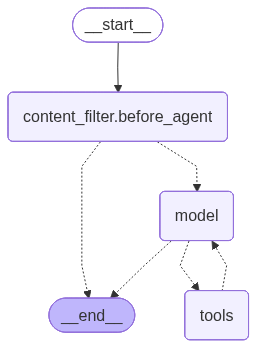

In [9]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: content_filter(@before_agent)가 금지어를 감지하면 즉시 END로 점프해요
# tools 노드: 금지어가 없는 정상 요청일 때만 도구를 실행해요
from IPython.display import Image, display

display(Image(agent_filter.get_graph().draw_mermaid_png()))

In [19]:
# 정상 요청은 가드레일을 통과해서 실행돼요
result = agent_filter.invoke({
    "messages": [{
        "role": "user",
        "content": "Python 프로그래밍에 대해 알려줘"
    }]
})
print(result["messages"][-1].content)

파이썬(Python)은 강력하고 사용하기 쉬운 고급 프로그래밍 언어입니다. 다음은 파이썬의 주요 특징과 장점입니다:

1. **문법의 단순성**: 파이썬은 다른 언어에 비해 문법이 간단하고 읽기 쉬워, 초보자에게 적합합니다.

2. **인터프리터 언어**: 파이썬은 인터프리터 방식으로 실행되므로, 코드를 한 줄씩 실행하고 디버깅하기 쉬워 빠른 프로토타이핑이 가능합니다.

3. **객체 지향 및 함수형 프로그래밍 지원**: 파이썬은 객체 지향 프로그래밍(OOP)과 함수형 프로그래밍을 모두 지원합니다.

4. **넓은 라이브러리 생태계**: 데이터 분석(예: NumPy, pandas), 웹 개발(예: Django, Flask), 머신러닝(예: TensorFlow, scikit-learn) 등 다양한 분야에서 이용할 수 있는 라이브러리가 풍부합니다.

5. **다양한 플랫폼 지원**: 파이썬은 Windows, macOS, Linux 등 다양한 운영 체제에서 실행될 수 있습니다.

6. **커뮤니티와 문서화**: 파이썬은 활발한 커뮤니티와 잘 갖춰진 문서화가 있어 학습과 문제 해결이 용이합니다.

### 기본적인 예제 코드

```python
# 간단한 파이썬 프로그램
def greet(name):
    return f"Hello, {name}!"

print(greet("World"))  # Hello, World!
```

### 파이썬 설치

1. [Python의 공식 웹사이트](https://www.python.org/downloads/)에서 다운로드합니다.
2. 설치 후 터미널(또는 명령 프롬프트)에서 `python` 또는 `python3`를 입력하여 설치가 잘 되었는지 확인합니다.

파이썬에 대해 더 알고 싶거나 특정 주제가 궁금하신 게 있다면 말씀해 주세요!


## 4. AgentMiddleware 클래스 - 재사용 가능한 가드레일

`@before_agent` 데코레이터는 간단한 로직에 좋지만, **설정 가능한 파라미터**가 필요하거나 **여러 훅을 한 클래스에서 관리**해야 할 때는 `AgentMiddleware`를 상속받아 클래스로 구현해요.

| 방식 | 사용 시기 | 장점 |
|------|----------|------|
| 데코레이터 (`@before_agent`) | 단순한 검증 로직 | 간결한 코드 |
| 클래스 (`AgentMiddleware` 상속) | 설정 파라미터 필요, 상태 유지 | 재사용성, 여러 훅 조합 |

> 💡 **실무 팁**: 클래스 기반 미들웨어는 패키지로 배포하거나 여러 에이전트에서 재사용할 때 훨씬 관리하기 좋아요. 프로덕션 환경에서는 클래스 방식을 더 추천해요.

In [20]:
# AgentMiddleware와 hook_config 임포트
from langchain.agents.middleware import AgentMiddleware, hook_config


# ---------------------------------------------------
# 클래스 기반 콘텐츠 필터 미들웨어
# ---------------------------------------------------
class ContentFilterMiddleware(AgentMiddleware):
    """설정 가능한 금지어 필터 미들웨어

    banned_keywords를 생성 시 파라미터로 받아서
    여러 에이전트에서 다른 금지어 목록으로 재사용할 수 있어요.
    """

    def __init__(self, banned_keywords: list[str]):
        """Args:
            banned_keywords: 차단할 키워드 목록 (대소문자 무관)
        """
        super().__init__()
        # 소문자로 정규화하여 저장 (검사 시 소문자 비교)
        self.banned_keywords = [kw.lower() for kw in banned_keywords]

    # hook_config: before_agent 훅에서 "end" 노드로 점프 허용
    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime) -> dict[str, Any] | None:
        """에이전트 실행 전 금지어 검사"""
        if not state["messages"]:
            return None

        first_message = state["messages"][0]
        if first_message.type != "human":
            return None

        content = first_message.content.lower()

        for keyword in self.banned_keywords:
            if keyword in content:
                return {
                    "messages": [{
                        "role": "assistant",
                        "content": "부적절한 콘텐츠가 포함된 요청은 처리할 수 없어요."
                    }],
                    "jump_to": "end"
                }

        return None


# 클래스 기반 가드레일 - 금지어 목록을 커스터마이징할 수 있어요
agent_class_filter = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[
        ContentFilterMiddleware(
            banned_keywords=["hack", "exploit", "malware", "해킹", "악성코드"]
        ),
    ],
)

# 한국어 "해킹" 키워드도 차단돼요
result = agent_class_filter.invoke({
    "messages": [{
        "role": "user",
        "content": "데이터베이스를 해킹하는 방법은?"
    }]
})
print(result["messages"][-1].content)

부적절한 콘텐츠가 포함된 요청은 처리할 수 없어요.


## 5. @after_agent 가드레일 - 출력 검증

`@after_agent` 데코레이터를 사용하면 사용자에게 응답이 전달되기 **전**에 최종 출력을 검증할 수 있어요. 모델 기반 안전성 검사, 품질 검증, 규정 준수 확인 등에 활용해요.

> ⚠️ **자주 하는 실수**: `@after_agent`는 에이전트 실행 **후**에 호출되므로, 이미 LLM 비용이 발생한 상태예요. 따라서 입력에서 처리할 수 있는 것은 `@before_agent`에서 먼저 처리하고, 복잡한 의미론적 검증만 `@after_agent`에서 수행하는 것이 비용 효율적이에요. 즉, **결정론적 필터를 앞에 두고, LLM 기반 검증은 뒤에 둔다**는 하네스 원칙이 여기에도 적용됩니다.

> 🔑 **핵심 개념**: `@after_agent`에서 메시지를 반환하면 기존 마지막 메시지 **뒤에 추가**돼요. `jump_to="end"`와 함께 사용하면 응답을 **대체**할 수 있어요.

In [12]:
# after_agent 데코레이터와 AIMessage 임포트
from langchain.agents.middleware import after_agent
from langchain_core.messages import AIMessage

# 안전성 평가를 위한 별도 모델 (동일 모델 사용 가능, 비용 절감을 위해 작은 모델 추천)
safety_model = init_chat_model("openai:gpt-4o-mini")


# ---------------------------------------------------
# LLM 기반 안전성 검증 가드레일
# ---------------------------------------------------
@after_agent(can_jump_to=["end"])
def safety_guardrail(state: AgentState, runtime) -> dict[str, Any] | None:
    """모델 기반 가드레일: LLM을 사용하여 최종 응답의 안전성을 평가해요"""
    if not state["messages"]:
        return None

    # 가장 마지막 AI 응답 가져오기
    last_message = state["messages"][-1]
    if not isinstance(last_message, AIMessage):
        return None

    # 안전성 평가 프롬프트: 'SAFE' 또는 'UNSAFE'로만 응답 요청
    safety_prompt = f"""이 응답이 안전하고 적절한지 평가해 주세요.
    'SAFE' 또는 'UNSAFE'로만 응답하세요.

    응답: {last_message.content}"""

    # 안전성 모델로 평가 실행
    eval_result = safety_model.invoke([{"role": "user", "content": safety_prompt}])

    if "UNSAFE" in eval_result.content:
        # UNSAFE 판정: 응답을 차단하고 안전 메시지로 대체
        return {
            "messages": [{
                "role": "assistant",
                "content": "해당 응답을 제공할 수 없어요. 다른 방식으로 도움을 드릴 수 있을지 알려주세요."
            }],
            "jump_to": "end"
        }

    # SAFE 판정: 안전 확인 메시지를 추가하고 정상 진행
    return {
        "messages": [{
            "role": "assistant",
            "content": f"[안전 검사 통과: {eval_result.content}]"
        }]
    }


# 안전성 검사가 적용된 에이전트
agent_safe = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[safety_guardrail],
)

# 안전한 요청 - 응답 후 안전 검사가 실행돼요
result = agent_safe.invoke({
    "messages": [{
        "role": "user",
        "content": "Python 프로그래밍의 장점을 알려줘"
    }]
})

# 마지막 두 메시지 출력 (AI 응답 + 안전 검사 결과)
for msg in result["messages"][-2:]:
    if isinstance(msg, AIMessage):
        print(f"[{msg.type}] {msg.content[:200]}")

[ai] Python 프로그래밍의 주요 장점은 다음과 같습니다:

1. **단순하고 가독성이 높은 문법**: Python은 코드가 간결하고 읽기 쉽게 설계되어 있어, 초보자들이 배우기 쉽고, 코드 유지보수가 용이합니다.

2. **범용성**: Python은 웹 개발, 데이터 분석, 인공지능, 머신러닝, 과학 계산 등 다양한 분야에서 사용됩니다. 따라서 여러 분야에 
[ai] [안전 검사 통과: SAFE]


## 6. Human-in-the-Loop 가드레일

민감한 작업 실행 전에 **사람의 승인**을 요구하는 것은 가장 강력한 가드레일 중 하나예요. `HumanInTheLoopMiddleware`를 사용하면 특정 도구 호출 전에 실행을 일시 중지하고 사람의 결정을 기다릴 수 있어요.

> 🔁 **복습 연결**: `HumanInTheLoopMiddleware` 자체와 approve/edit/reject/respond 결정 타입은 `02-Human-In-The-Loop-V1.ipynb`에서 자세히 배웠어요. 여기서는 그 HITL을 **여러 방어선 중 하나(사람 승인 계층)**로 재배치하는 관점만 봅니다.

**HITL이 유용한 경우:**
- 금융 거래 및 환불 처리
- 이메일 / 메시지 전송
- 데이터 삭제 또는 수정
- 비즈니스에 중요한 외부 API 호출

> 💡 **실무 팁**: `HumanInTheLoopMiddleware`는 내부적으로 LangGraph의 `interrupt`를 사용해요. 따라서 반드시 `checkpointer=InMemorySaver()`를 설정해야 하고, 재개(resume)할 때 동일한 `thread_id`를 사용해야 해요.

In [13]:
# HITL 관련 임포트
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command


@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Send an email. This is a sensitive operation."""
    # 이메일 전송 (민감한 작업 - 승인 필요)
    return f"Email sent to {recipient} with subject '{subject}'"


@tool
def delete_record_tool(record_id: str) -> str:
    """Delete a record. This is a critical operation."""
    # 레코드 삭제 (위험한 작업 - 승인 필요)
    return f"Record {record_id} deleted"


# HITL 미들웨어가 적용된 에이전트
# checkpointer 필수: 승인 대기 중 상태를 저장해야 재개(resume)가 가능해요
agent_hitl = create_agent(
    model=model,
    tools=[search_tool, send_email_tool, delete_record_tool],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": True,    # 이메일 전송 전 승인 필요
                "delete_record_tool": True, # 레코드 삭제 전 승인 필요
                "search_tool": False,       # 검색은 자동 승인 (안전한 작업)
            }
        ),
    ],
    checkpointer=InMemorySaver(),  # 상태 지속성 필수
)

# thread_id: 대화 상태를 추적하는 식별자
config = {"configurable": {"thread_id": "hitl_demo_thread"}}

# --- 1단계: 에이전트 실행 (이메일 전송 전 일시 중지 예상) ---
# 이메일 전송 시도 → HITL에 의해 일시 중지돼요
for chunk in agent_hitl.stream(
    {"messages": [{"role": "user", "content": "Send email to team@company.com: subject 'Update', body 'Please review.'"}]},
    config,
    stream_mode="updates"
):
    for node_name, node_output in chunk.items():
        print(f"\n[노드: {node_name}]")
        if node_output is not None and "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "pretty_print"):
                    msg.pretty_print()


[노드: model]
================================== Ai Message ==================================
Tool Calls:
  send_email_tool (call_gpex5g3tUBHuANVazwtDThWU)
 Call ID: call_gpex5g3tUBHuANVazwtDThWU
  Args:
    recipient: team@company.com
    subject: Update
    body: Please review.

[노드: __interrupt__]


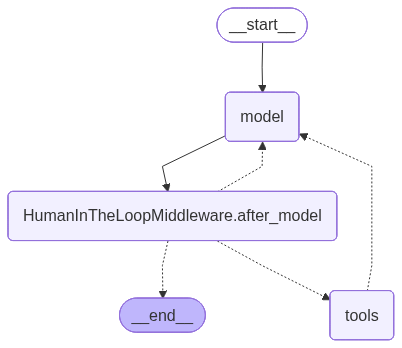

In [14]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# agent 노드: send_email_tool과 delete_record_tool 호출 시 HITL interrupt가 발생해요
# search_tool은 자동 실행 (안전한 작업)
# checkpointer(InMemorySaver)가 interrupt 상태를 저장하고 Command(resume=)로 재개해요
from IPython.display import Image, display
display(Image(agent_hitl.get_graph().draw_mermaid_png()))

In [ ]:
# --- 2단계: 승인 후 재개 ---
# Command(resume=) 으로 승인 결정을 전달하여 에이전트를 재개해요
for chunk in agent_hitl.stream(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config,  # 동일한 thread_id로 재개
    stream_mode="updates"
):
    for node_name, node_output in chunk.items():
        print(f"\n[노드: {node_name}]")
        if node_output is not None and "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "pretty_print"):
                    msg.pretty_print()


[노드: HumanInTheLoopMiddleware.after_model]
================================== Ai Message ==================================
Tool Calls:
  send_email_tool (call_gpex5g3tUBHuANVazwtDThWU)
 Call ID: call_gpex5g3tUBHuANVazwtDThWU
  Args:
    recipient: team@company.com
    subject: Update
    body: Please review.

[노드: tools]
================================= Tool Message =================================
Name: send_email_tool

Email sent to team@company.com with subject 'Update'

[노드: model]
================================== Ai Message ==================================

The email has been successfully sent to team@company.com with the subject "Update" and the body "Please review."

[노드: HumanInTheLoopMiddleware.after_model]


## 7. 계층화된 방어 (Defense in Depth)

실무 환경에서는 단일 가드레일로 충분하지 않아요. 여러 가드레일을 **올바른 순서로** 조합하면 한 계층이 실패해도 다른 계층이 보호해요.

### 권장 가드레일 순서

```
빠름 ←─────────────────────────────────────→ 느림
저비용 ←────────────────────────────────── 고비용

1. 결정론적 필터  →  2. PII 보호  →  3. HITL  →  4. 모델 기반 검증
   (regex, ms)       (regex, ms)    (사람 개입)    (LLM, 초 단위)
```

> 🎯 **강의 포인트**: 빠른 검사를 먼저 배치하는 이유가 있어요. 금지어로 차단되어야 할 요청이 LLM 안전성 검사까지 도달하면 비용이 낭비되고, 예상치 못한 응답이 생성될 위험도 있어요. **입구를 좁혀서 비용을 줄이는** 것이 핵심이에요.

> 단, HITL은 항상 "모델 기반 검증보다 앞"이라는 뜻은 아니에요. HITL은 보통 결제·삭제·전송처럼 **외부 상태가 바뀌기 직전**에 둡니다. 순서는 워크플로 위험도에 맞게 조정하되, 싼 결정론적 검사는 가능한 앞에 두세요.

> 💡 **실무 팁**: 미들웨어 배열은 `before_*` 훅은 배열 **정순**으로, `after_*` 훅은 배열 **역순**으로 실행돼요. `[A, B, C]` 순서로 등록하면: before는 `A→B→C`, after는 `C→B→A` 순서예요.

In [16]:
# ---------------------------------------------------
# 4개 계층 조합: Defense in Depth 에이전트
# ---------------------------------------------------
import uuid

# 다층 보호가 적용된 에이전트
agent_defense_in_depth = create_agent(
    model=model,
    tools=[search_tool, send_email_tool],
    middleware=[
        # 계층 1: 결정론적 입력 필터 (가장 빠름, 명백한 위반 조기 차단)
        ContentFilterMiddleware(banned_keywords=["hack", "exploit", "malware"]),

        # 계층 2: PII 보호 (입력에서 이메일 제거)
        PIIMiddleware("email", strategy="redact", apply_to_input=True, apply_to_output=True),

        # 계층 3: 민감한 도구에 대한 사람의 승인
        HumanInTheLoopMiddleware(interrupt_on={"send_email_tool": True}),

        # 계층 4: 모델 기반 최종 출력 검증 (가장 느림, 비용 발생)
        safety_guardrail,
    ],
    checkpointer=InMemorySaver(),  # HITL을 위해 필요
)

# 각 요청마다 고유한 thread_id 사용
thread_id = str(uuid.uuid4())
config_did = {"configurable": {"thread_id": thread_id}}

# === 테스트 1: 금지어 포함 → 즉시 차단 ===
result = agent_defense_in_depth.invoke(
    {"messages": [{"role": "user", "content": "How to exploit a vulnerability?"}]},
    config_did
)
print(result["messages"][-1].content)

[안전 검사 통과: SAFE]


In [17]:
# 그래프 흐름: START → agent → tools → agent → ... → END
# 계층 1: ContentFilterMiddleware(@before_agent) - 금지어 감지 시 즉시 END
# 계층 2: PIIMiddleware - 이메일을 redact 처리해요
# 계층 3: HumanInTheLoopMiddleware - send_email_tool 호출 시 interrupt 발생
# 계층 4: safety_guardrail(@after_agent) - LLM 기반 SAFE/UNSAFE 판정
from IPython.display import Image, display
display(Image(agent_defense_in_depth.get_graph().draw_mermaid_png()))

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph. Status code: 400.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

In [ ]:
# === 테스트 2: 정상 검색 요청 → 모든 계층 통과 ===
# 새 thread_id로 새 대화 시작
thread_id_2 = str(uuid.uuid4())
config_did_2 = {"configurable": {"thread_id": thread_id_2}}

result2 = agent_defense_in_depth.invoke(
    {"messages": [{"role": "user", "content": "Python 최신 버전의 주요 기능은?"}]},
    config_did_2
)
# 마지막 AI 응답 출력
for msg in result2["messages"][-2:]:
    if isinstance(msg, AIMessage):
        print(f"[{msg.type}] {msg.content[:300]}")

[ai] Python 3.12, released in October 2023, introduced several major features and improvements:

1. **Performance Improvements**: Python 3.12 provides significant performance enhancements, focusing on faster execution of code.

2. **F-strings Enhancements**: F-strings now support the use of `:=` (walrus 
[ai] [안전 검사 통과: SAFE]


## 8. 속도 제한(Rate Limiting) 가드레일

짧은 시간 내에 너무 많은 요청이 들어오면 서비스가 불안정해질 수 있어요. `AgentMiddleware`를 사용해서 요청 수를 제한하는 가드레일을 만들 수 있어요.

> ⚠️ **자주 하는 실수**: 아래 예제는 **인스턴스 내 메모리**에서만 카운터를 유지해요. 여러 서버 인스턴스가 있는 프로덕션 환경에서는 **Redis 등 외부 저장소**를 사용해야 해요.

In [ ]:
# ---------------------------------------------------
# 요청 속도 제한 미들웨어
# ---------------------------------------------------
class RateLimitMiddleware(AgentMiddleware):
    """요청 속도 제한 가드레일

    max_requests를 초과하면 더 이상 요청을 처리하지 않아요.
    프로덕션에서는 Redis 등 외부 저장소로 분산 카운터를 구현해야 해요.
    """

    def __init__(self, max_requests: int = 10):
        """Args:
            max_requests: 허용되는 최대 요청 수
        """
        super().__init__()
        self.request_count = 0            # 현재 요청 수 카운터
        self.max_requests = max_requests  # 최대 허용 요청 수

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime) -> dict[str, Any] | None:
        """에이전트 실행 전 요청 수 확인"""
        self.request_count += 1

        if self.request_count > self.max_requests:
            # 한도 초과 시 에이전트 실행을 차단해요
            return {
                "messages": [{
                    "role": "assistant",
                    "content": f"요청 한도({self.max_requests}회)를 초과했어요. 잠시 후 다시 시도해 주세요."
                }],
                "jump_to": "end"
            }
        return None


# 속도 제한이 적용된 에이전트 (테스트를 위해 max_requests=2로 설정)
rate_limiter = RateLimitMiddleware(max_requests=2)
agent_rate_limited = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[rate_limiter],
)

# 3번 요청 - 3번째는 차단돼요
for i in range(3):
    result = agent_rate_limited.invoke({
        "messages": [{"role": "user", "content": f"요청 #{i+1}: Python이란?"}]
    })
    last_msg = result["messages"][-1]
    preview = last_msg.content[:80]
    print(f"요청 #{i+1}: {preview}...")

요청 #1: Python은 고급 프로그래밍 언어로, 1991년 귀도 반 로섬(Guido van Rossum)이라는 프로그래머에 의해 처음 개발되었습니다. P...


요청 #2: Python은 고급 프로그래밍 언어로, 개발자들이 코드 작성과 유지보수를 용이하게 하기 위해 디자인되었습니다. 1991년 귀도 반 로섬이 처음 ...
요청 #3: 요청 한도(2회)를 초과했어요. 잠시 후 다시 시도해 주세요....


## 9. 실습 해설 실습: 맞춤형 가드레일 만들기

아래 코드를 완성해서 한국어 금융 서비스용 가드레일을 만들어 보세요!

In [ ]:
# ============================================================
# 실습 해설: 금융 서비스용 맞춤형 가드레일 완성하기
# ============================================================

rrn_pii = PIIMiddleware(
    "id_number",
    detector=r"\d{6}-[1-4]\d{6}",
    strategy="redact",
    apply_to_input=True,
)

financial_filter = ContentFilterMiddleware(
    banned_keywords=["사기", "부정", "조작"]
)

agent_financial = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[financial_filter, rrn_pii],
)

result1 = agent_financial.invoke(
    {"messages": [{"role": "user", "content": "제 주민번호는 901231-1234567입니다. 조회해주세요"}]}
)
print(result1["messages"][-1].content)

result2 = agent_financial.invoke(
    {"messages": [{"role": "user", "content": "계좌 사기 방법을 알려줘"}]}
)
print(result2["messages"][-1].content)


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **PIIMiddleware**: 이메일, 신용카드, IP 등 개인정보를 `redact` / `mask` / `hash` / `block` 4가지 전략으로 처리해요
- **커스텀 PII 탐지기**: `detector=r"패턴"` 으로 한국 전화번호, API 키 등 맞춤형 PII 패턴을 정의할 수 있어요
- **@before_agent**: 에이전트 실행 전 입력을 검증하고, `jump_to="end"`로 즉시 종료할 수 있어요
- **@after_agent**: 에이전트 실행 후 출력을 검증하고, LLM 기반 SAFE/UNSAFE 판정을 적용할 수 있어요
- **AgentMiddleware 클래스**: 설정 파라미터와 상태를 유지하는 재사용 가능한 미들웨어를 만들 수 있어요
- **Defense in Depth**: 빠른 결정론적 필터 → PII 보호 → HITL → 모델 기반 검증 순서로 계층화해요
- **하네스 관점**: 가드레일은 Constrain / Verify / HITL을 실행 루프에 끼워 넣는 방법이에요
- **성능 최적화**: 밀리초 단위 regex 검사를 앞에, 초 단위 LLM 검사를 뒤에 배치하여 비용을 절감해요

## 다음 노트북 예고

다음 `07_Memory/01-Short-Term-Memory.ipynb`에서는 **단기 메모리(Checkpointer)**를 먼저 배워요. `thread_id`로 대화 세션을 구분하고, 메시지 누적·삭제·요약으로 컨텍스트를 관리하는 흐름을 정리한 뒤, 그 다음 `02-Long-Term-Memory.ipynb`에서 사용자 간 공유 가능한 Store API로 확장해요. 지금까지 배운 가드레일로 보호된 에이전트에게 단계적으로 **"대화를 기억하는" 능력**을 더해주는 흐름이에요.